### APS1070 Project 3 - Part 1, Git Practice

**Academic Integrity**

This project is individual - it is to be completed on your own. If you have questions, please post your query in the APS1070 Piazza Q&A forums (the answer might be useful to others!).

Do not share your code with others, or post your work online. Do not submit code that you have not written yourself. Students suspected of plagiarism on a project, midterm or exam will be referred to the department for formal discipline for breaches of the Student Code of Conduct.

Please fill out the following:


*   Your **Taha Baig**:
*   Your **1012848475**:



## Part 1: Getting started with GitHub [1.5 Marks + 2 Mark Git Submission]


For the first four parts (Part 1-4) of this project, we will work on a [population of countries dataset](https://ourworldindata.org/grapher/population) which reports the population of over 200 countries worldwide from 10000 BCE to 2023. Download the dataset in .csv format using the provided code below. Using the Pandas package, create a population dataframe with only the countries provided in [this GitHub list](https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt) (237 countries - you should remove all other entities) as rows and years from 1901 to 2023 (123 years) as columns. Then, remove all the countries that have at least missing or invalid value over the years.

In [ ]:
import pandas as pd
import requests, io

headers = {"User-Agent": "Mozilla/5.0"}
raw_data = pd.read_csv(
    filepath_or_buffer=io.StringIO(requests.get(
        'https://ourworldindata.org/grapher/population.csv?v=1&csvType=full&useColumnShortNames=true',
        headers=headers).text),
    index_col=False)

countries_list_url = "https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt"

In [ ]:
# Clean column names
raw_data.columns = raw_data.columns.str.strip()

# Check column names
print(raw_data.columns)


Index(['entity', 'code', 'year', 'population_historical'], dtype='object')


In [ ]:
# This command download the country-list text file from GitHub, read it as text, and split it into a list where each country is one item.
countries_list = requests.get(countries_list_url, headers=headers).text.splitlines()

# Remove empty spaces and empty lines
countries_list = [country.strip() for country in countries_list if country.strip()]

print(len(countries_list))
print(countries_list[:10])

237
['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra', 'Angola', 'Anguilla', 'Antigua and Barbuda', 'Argentina', 'Armenia']


In [ ]:
# Years required by the project
years = list(range(1901, 2024))

# Keep only required columns
df = raw_data[["entity", "year", "population_historical"]].copy()

# Keep only countries from the GitHub country list
df = df[df["entity"].isin(countries_list)]

# Keep only years from 1901 to 2023
df = df[df["year"].between(1901, 2023)]

# Convert population values to numeric if there is any invalid, make it NaN
df["population_historical"] = pd.to_numeric(df["population_historical"], errors="coerce")

# Convert long format to wide format
population_df = df.pivot(index="entity",columns="year",values="population_historical")

# To ensure that columns are exactly 1901 to 2023
population_df = population_df.reindex(columns=years)

# Remove countries with missing values
population_df = population_df.dropna()

# Remove countries with invalid population values
population_df = population_df[(population_df > 0).all(axis=1)]

# Check final dataframe
print(population_df.shape)
population_df.head()

(196, 123)


year,1901,1902,1903,1904,1905,1906,1907,1908,1909,1910,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
entity,,,,,,,,,,,,,,,,,,,,,
Afghanistan,4751177.0,4802500.0,4861833.0,4921891.0,4982681.0,5044212.0,5106495.0,5169536.0,5300178.0,5504191.0,...,32792528.0,33831767.0,34700613.0,35688941.0,36743040.0,37856125.0,39068977.0,40000410.0,40578847.0,41454762.0
Albania,813539.0,821036.0,828461.0,835954.0,843514.0,851143.0,858841.0,866609.0,874016.0,881057.0,...,2903748.0,2898634.0,2897868.0,2898245.0,2894229.0,2885011.0,2871950.0,2849641.0,2827614.0,2811660.0
Algeria,4787149.0,4859600.0,4939332.0,5020372.0,5102742.0,5186463.0,5271557.0,5358048.0,5433528.0,5497750.0,...,39205035.0,40019528.0,40850719.0,41689302.0,42505033.0,43294551.0,44042094.0,44761099.0,45477391.0,46164222.0
Andorra,4551.0,4581.0,4610.0,4640.0,4670.0,4700.0,4730.0,4761.0,4802.0,4855.0,...,73755.0,72195.0,72197.0,73780.0,75181.0,76492.0,77397.0,78379.0,79722.0,80869.0
Angola,3083888.0,3064493.0,3043335.0,3022320.0,3001447.0,2980714.0,2960121.0,2939666.0,2921666.0,2906100.0,...,27160767.0,28157802.0,29183072.0,30234836.0,31297160.0,32375633.0,33451139.0,34532427.0,35635028.0,36749909.0


1. Write a function to do the following: **[0.5]**
    * Takes the dataframe, and your list of countries/regions as inputs (Afghanistan, Albania, Algeria, ...)
    * Plots time-series for the input list (it is best to plot each country in a separate graph (subplot), so you can easily compare them.)
    
2. Apply `StandardScalar` to the data. Each year should have a `mean` of zero and a `StD` of 1. **[0.25]**
3. Pick two countries whose names are closest to your first name using string edit distance.
Hint: you can use `Levenshtein.distance()` from the python-Levenshtein package. You may find [this link](https://www.geeksforgeeks.org/python/introduction-to-python-levenshtein-module/) helpful.
4. Run the function in `step 1` on both the original as well as the standardized dataset for the two countries you picked in `step 3` plus `Japan`, `Bosnia and Herzegovina`, `Latvia`, and `United Arab Emirates`. (If you have already selected one of these countries, go down the list and pick the next one you haven't selected) **[0.25]**
5. Discuss the trends in the standardized time-series for all these countries. What does it mean if the curve goes up or down? What does the sign of values indicate? **[0.5]**

In [ ]:
import matplotlib.pyplot as plt

def plot_country_timeseries(df, country_list, title, ylabel):
    # Keep only countries that actually exist in the dataframe
    available_countries = [country for country in country_list if country in df.index]

    # I use this for finding missing countries
    missing_countries = [country for country in country_list if country not in df.index]

    if missing_countries:
        print("These countries are not available in the dataframe:")
        print(missing_countries)

    # Number of countries to plot
    n = len(available_countries)

    # Create one subplot for each country and all subplots will share the same x-axis.
    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(12, 3*n), sharex=True)

    # If only one country is selected, axes is not a list, so convert it to a list
    if n == 1:
        axes = [axes]

    # Plot each country separately
    for ax, country in zip(axes, available_countries):
        ax.plot(df.columns, df.loc[country])
        ax.set_title(country)
        ax.set_ylabel(ylabel)
        ax.grid(True)

    axes[-1].set_xlabel("Year")
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

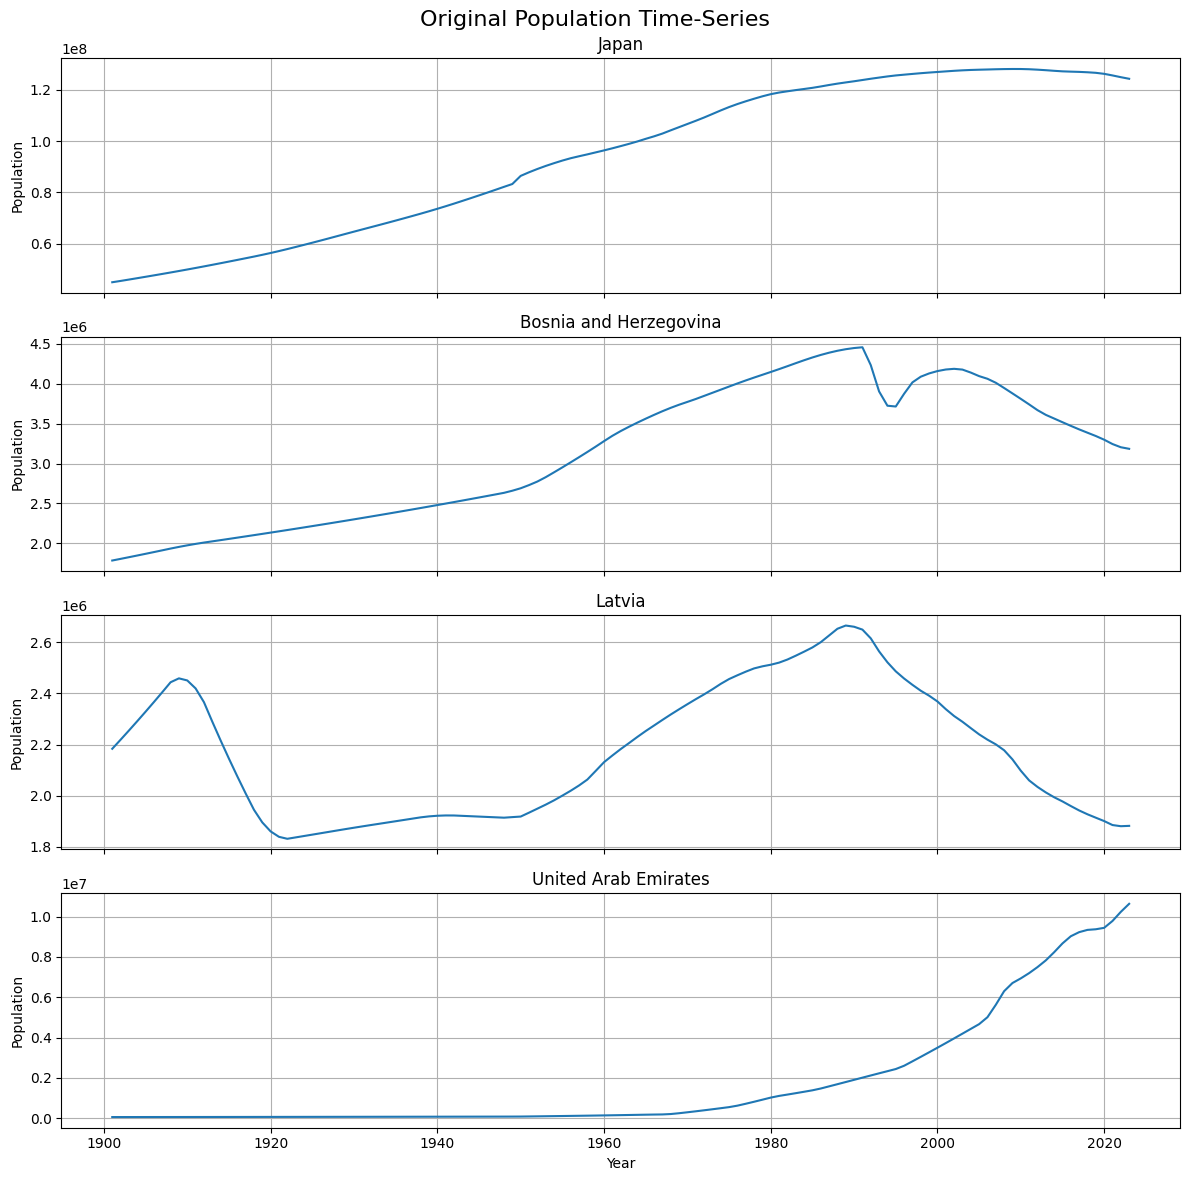

In [ ]:
countries_to_plot = [ "Japan","Bosnia and Herzegovina","Latvia","United Arab Emirates"]
plot_country_timeseries(df=population_df,country_list=countries_to_plot,title="Original Population Time-Series",ylabel="Population")

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Create StandardScaler object
scaler = StandardScaler()

# Apply StandardScaler column-wise
# Since columns are years, each year will have mean 0 and std 1
scaled_values = scaler.fit_transform(population_df)

# Convert scaled values back to dataframe
population_scaled_df = pd.DataFrame(scaled_values,index=population_df.index,columns=population_df.columns)

# Check that each year has mean close to 0
print(population_scaled_df.mean(axis=0).head())

# Check that each year has standard deviation close to 1
print(population_scaled_df.std(axis=0, ddof=0).head())

year
1901    0.000000e+00
1902   -1.812609e-17
1903   -1.812609e-17
1904    0.000000e+00
1905   -9.063045e-18
dtype: float64
year
1901    1.0
1902    1.0
1903    1.0
1904    1.0
1905    1.0
dtype: float64


In [ ]:
!pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 54.0 MB/s eta 0:00:00


In [ ]:
import Levenshtein

first_name = "Taha"

# These countries are already required in step 4,
# so I exclude them while selecting my own two countries
required_countries = ["Japan","Bosnia and Herzegovina","Latvia","United Arab Emirates"]

# Candidate countries should not include the already required countries
candidate_countries = [country for country in population_df.index
    if country not in required_countries]

# Calculate Levenshtein distance between my name and each country
distance_results = []

for country in candidate_countries:
    distance = Levenshtein.distance(first_name.lower(), country.lower())
    distance_results.append([country, distance])

# Convert to dataframe
distance_df = pd.DataFrame(distance_results,columns=["Country", "Levenshtein Distance"])

# Sort by smallest distance
distance_df = distance_df.sort_values(by=["Levenshtein Distance", "Country"])

# Display closest countries
display(distance_df.head(10))

# Pick the top 2 closest countries
picked_countries = distance_df.head(2)["Country"].tolist()

print("Two selected countries are:")
print(picked_countries)

,Country,Levenshtein Distance
32,Chad,3
41,Cuba,3
65,Ghana,3
82,Italy,3
90,Laos,3
102,Mali,3
103,Malta,3
129,Palau,3
138,Qatar,3
145,Samoa,3


Two selected countries are:
['Chad', 'Cuba']


In [ ]:
countries_to_plot = picked_countries + [
    "Japan",
    "Bosnia and Herzegovina",
    "Latvia",
    "United Arab Emirates"
]

print(countries_to_plot)

['Chad', 'Cuba', 'Japan', 'Bosnia and Herzegovina', 'Latvia', 'United Arab Emirates']


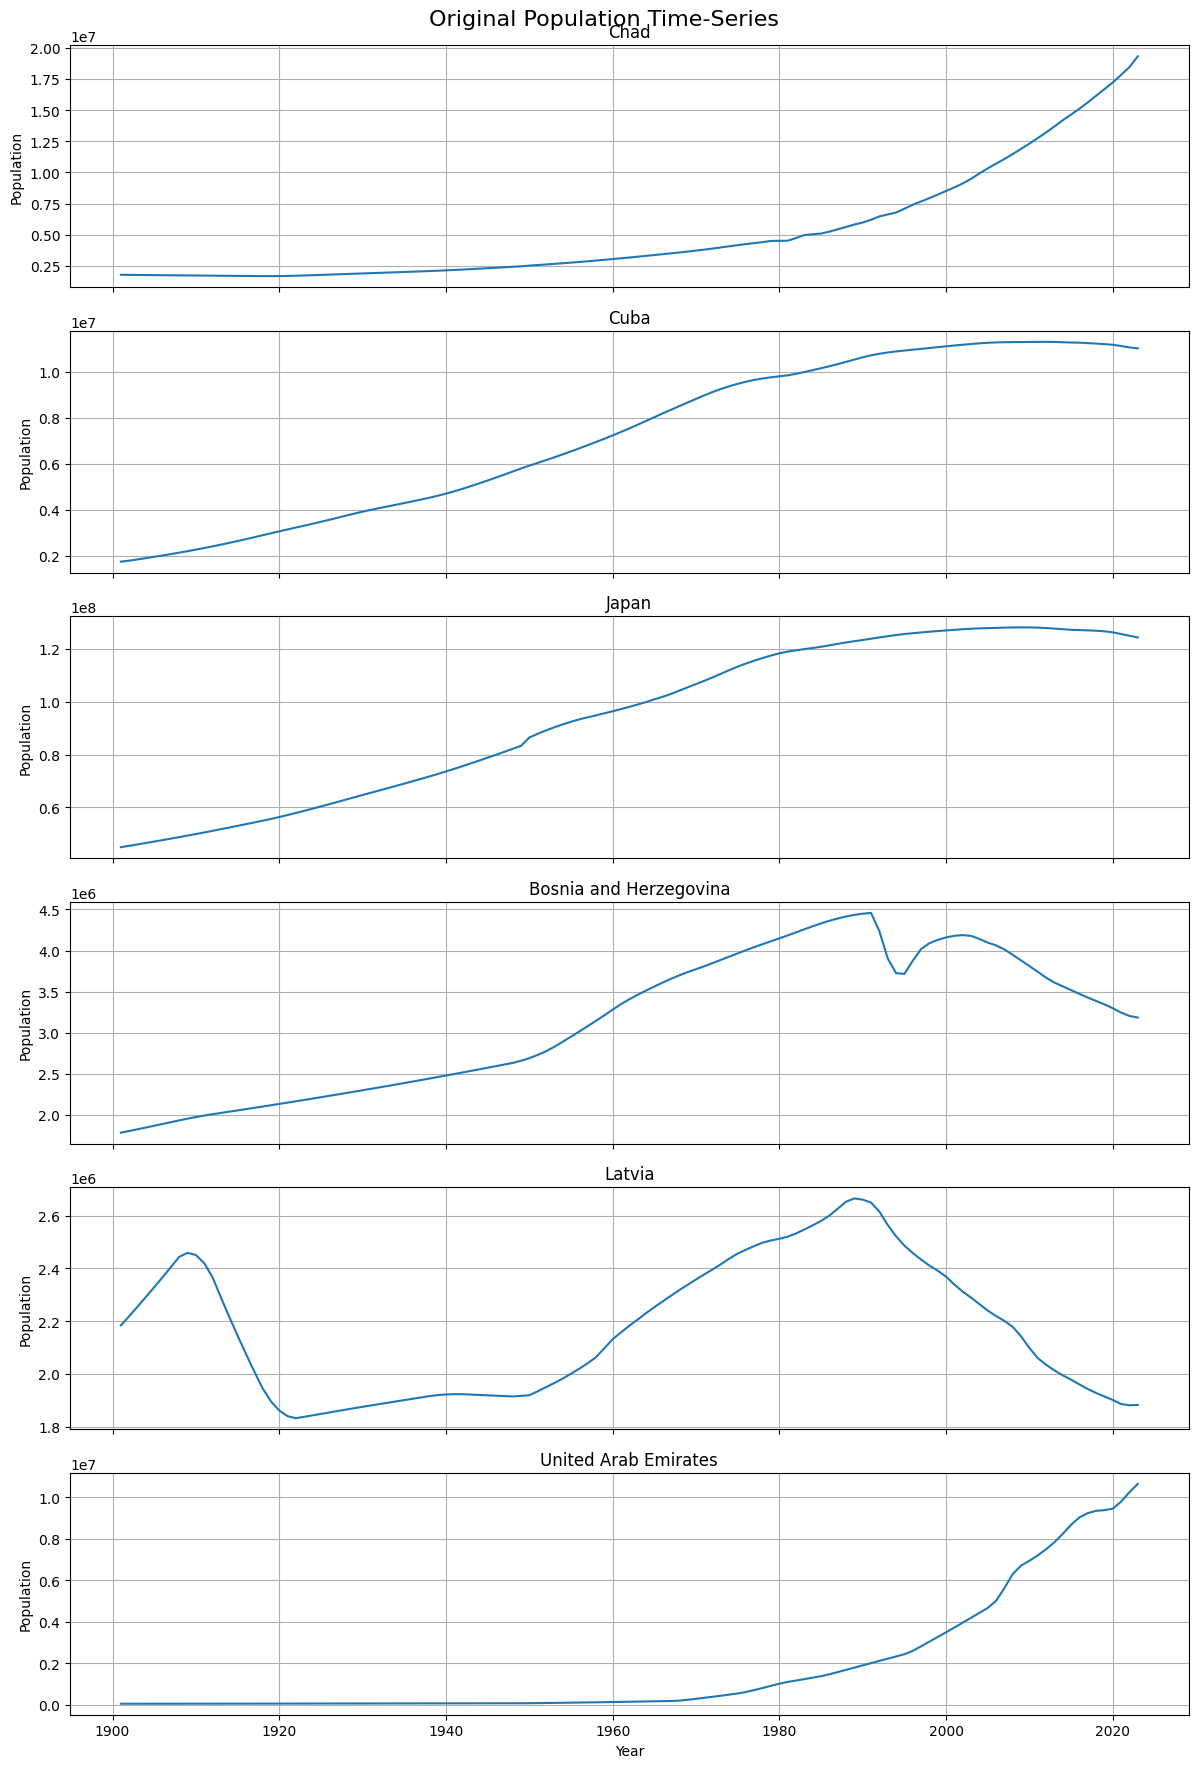

In [ ]:
plot_country_timeseries(
    df=population_df,
    country_list=countries_to_plot,
    title="Original Population Time-Series",
    ylabel="Population"
)

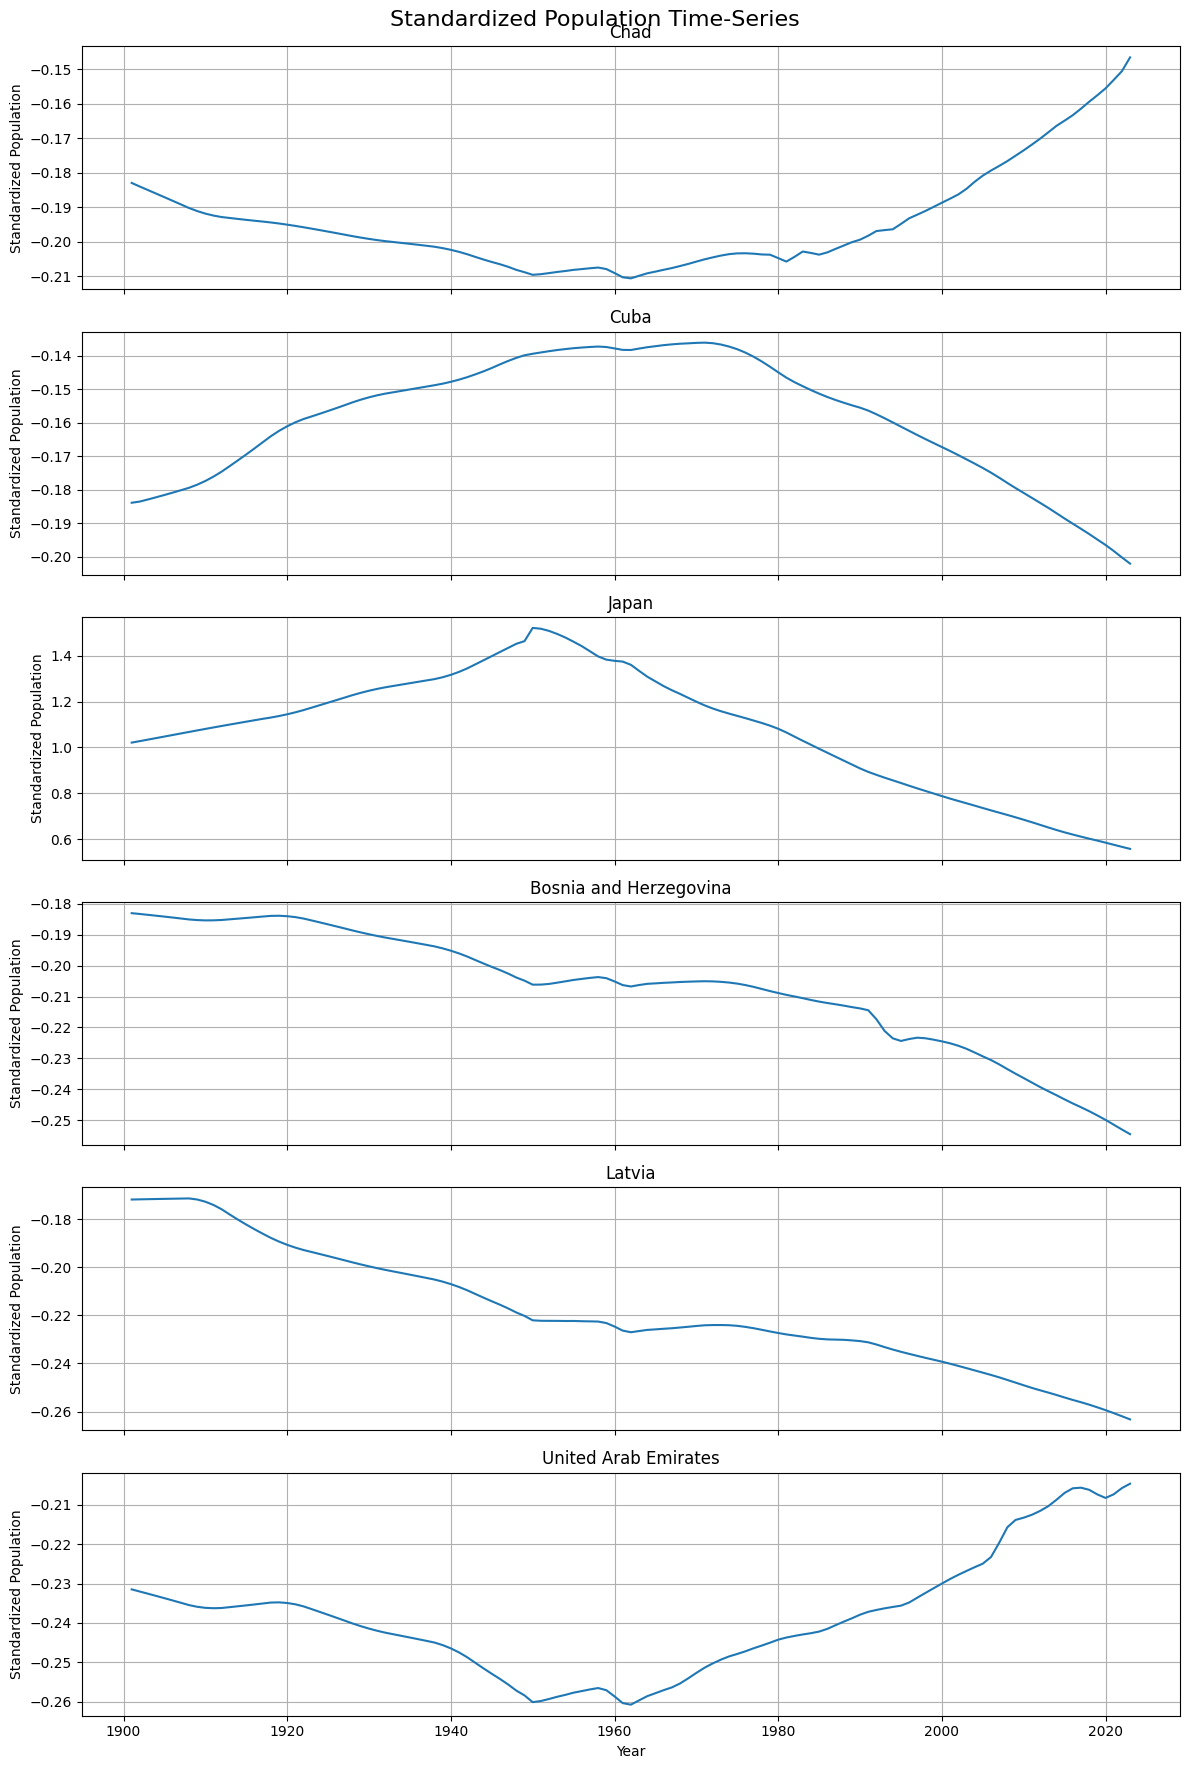

In [ ]:
plot_country_timeseries(
    df=population_scaled_df,
    country_list=countries_to_plot,
    title="Standardized Population Time-Series",
    ylabel="Standardized Population"
)

Chad

Chad’s standardized curve is negative for the whole period, which means its population is below the average country population in every year. The curve decreases slightly until around the middle of the 20th century, meaning Chad became relatively smaller compared with other countries. After that, the curve starts increasing strongly, especially after 1980. This means Chad’s population grew faster relative to many other countries, but it still remained below the yearly average.

Cuba

Cuba’s standardized curve is also negative throughout the period. It rises from 1901 to around the 1960s or 1970s, meaning Cuba’s population was improving relative to the average country. After that, the curve goes downward. This means Cuba’s population growth became slower compared with other countries. Even though Cuba’s original population increased for much of the period, its standardized value decreased later because other countries grew faster.

Japan

Japan has positive standardized values for the whole period. This means Japan’s population was above the average country population in every year. The curve rises until around the 1950s, showing that Japan became even larger relative to other countries. After that, the curve declines steadily. This means Japan was still above average, but its relative position decreased over time, likely because Japan’s population growth slowed while many other countries continued growing faster.

Bosnia and Herzegovina

Bosnia and Herzegovina has negative standardized values throughout the period, so its population was below the yearly average. The curve generally decreases over time, meaning its population became smaller relative to other countries. There is a noticeable drop around the 1990s, which shows a stronger relative decline during that period. Overall, Bosnia and Herzegovina moved further below the average population level.

Latvia

Latvia also stays negative for the whole period. Its standardized curve generally goes downward, especially after the mid-20th century. This means Latvia’s population became smaller relative to other countries over time. Even if the original population had some increases earlier, the standardized curve shows that Latvia did not grow as fast as the average country.

United Arab Emirates

The United Arab Emirates has negative standardized values throughout the period, meaning its population was below the yearly average. The curve decreases until around the 1960s, but after that it rises strongly. This shows that the UAE’s population grew very rapidly relative to other countries, especially after 1970. However, because the values are still negative, its population was still below the average country population in 2023.



